In [82]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [85]:
# Load data
df = pd.read_csv("hr_cleaned.csv")

# Clean missing values
df = df.dropna(subset=['Termd'])
df = df.fillna(df.mean(numeric_only=True))
df = df.dropna()

# Split data
X = df.drop(columns=["Termd"])
y = df["Termd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [86]:
# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# Evaluate
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("── Test set results ───────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active (0)", "Terminated (1)"]))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}\n")

── Test set results ───────────────────────────────────────
                precision    recall  f1-score   support

    Active (0)       0.77      0.86      0.81        42
Terminated (1)       0.62      0.48      0.54        21

      accuracy                           0.73        63
     macro avg       0.70      0.67      0.67        63
  weighted avg       0.72      0.73      0.72        63

  ROC-AUC : 0.785



In [87]:
# Generate Top 10 Risk Dashboard
df_risques = df.loc[X_test.index].copy()
df_risques['Risque_Depart_Proba'] = y_proba
df_risques['ID_Employe_Provisoire'] = df_risques.index 

df_top_risques = df_risques.sort_values(by='Risque_Depart_Proba', ascending=False)
colonnes_utiles = ['ID_Employe_Provisoire', 'DeptID', 'Salary', 'Risque_Depart_Proba'] 

tableau_epure = df_top_risques[colonnes_utiles].head(10)

print("🚀 TOP 10 DES EMPLOYÉS À RETENIR EN PRIORITÉ :\n")
print(tableau_epure.to_string(index=False))

🚀 TOP 10 DES EMPLOYÉS À RETENIR EN PRIORITÉ :

 ID_Employe_Provisoire  DeptID  Salary  Risque_Depart_Proba
                   151       5   54005             0.750883
                    89       5   57748             0.748576
                   122       5   54828             0.656537
                   280       5   67176             0.645165
                   224       5   46799             0.623643
                   302       5   58062             0.606561
                   112       5   68898             0.592638
                    69       5   53189             0.583799
                   233       5   64971             0.582251
                   165       5   64738             0.555409


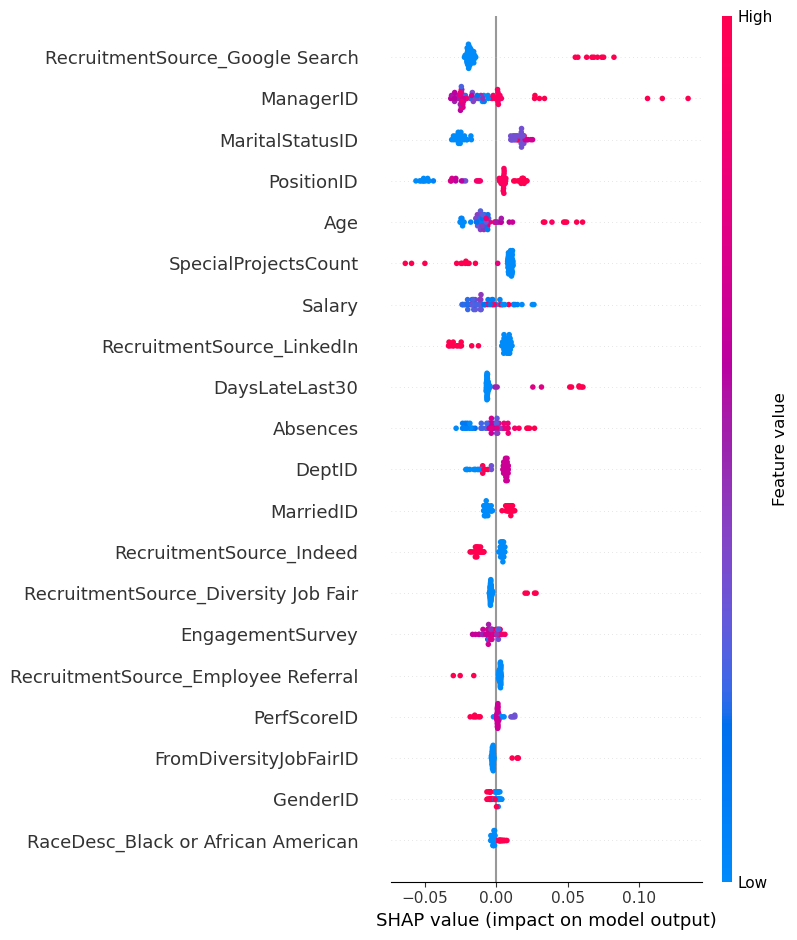

In [88]:
# SHAP Global Summary
shap.initjs()
explainer = shap.TreeExplainer(rf)
shap_vals_all = explainer.shap_values(X_test)

if isinstance(shap_vals_all, list):
    shap_vals_class1 = shap_vals_all[1]
elif len(np.array(shap_vals_all).shape) == 3:
    shap_vals_class1 = shap_vals_all[:, :, 1]
else:
    shap_vals_class1 = shap_vals_all

shap.summary_plot(shap_vals_class1, X_test)

In [94]:
# SHAP Local Explainer Function
def analyser_employe(id_employe):
    single_row_df = X_test.loc[[id_employe]]
    shap_vals_single = explainer.shap_values(single_row_df)
    
    if isinstance(shap_vals_single, list):
        sv = shap_vals_single[1]
        bv = explainer.expected_value[1]
    elif len(np.array(shap_vals_single).shape) == 3:
        sv = shap_vals_single[0, :, 1]
        bv = explainer.expected_value[1]
    else:
        sv = shap_vals_single
        bv = explainer.expected_value

    bv_scalar = float(np.asarray(bv).flatten()[0])
    sv_1d = np.array(sv).flatten()
    features_1d = single_row_df.values.flatten()
    noms_colonnes = single_row_df.columns.tolist()

    if len(sv_1d) == len(features_1d) + 1:
        sv_1d = sv_1d[:-1]

    taille_min = min(len(sv_1d), len(features_1d))
    
    return shap.force_plot(
        bv_scalar, 
        sv_1d[:taille_min], 
        features_1d[:taille_min], 
        feature_names=noms_colonnes[:taille_min]
    )

# Test function with top risk employee
id_a_tester = tableau_epure.iloc[3]['ID_Employe_Provisoire']
analyser_employe(id_a_tester)